## Document Clustering

The main premise of document clustering is similar to that of document categorization, where you start with a whole corpus of documents and are tasked with segregating them into various groups based on some distinctive properties, attributes, and features of the documents. Document classification needs pre-labeled training data to build a model and then categorize documents. Document clustering uses unsupervised ML algorithms to group the documents into various clusters. The properties of these clusters are such that documents inside one cluster are more similar and related to each other compared to documents belonging to other clusters. Figure 6-3, courtesy of scikit-learn, visualizes an example of clustering data points into three clusters based on its features

<img src="imgs/clust.png" width="450" height="550">

The cluster analysis in Figure 6-3 depicts three clusters among the data points, which are visualized using different colors. An important thing to remember here is that clustering is an unsupervised learning technique, and from Figure 6-3 it is pretty clear that there will always be some overlap among the clusters because there is no such definition of a perfect cluster. All the techniques are based on math, heuristics, and some inherent attributes toward generating clusters, and they are never a 100 percent perfect. Hence, there are several techniques or methods for finding clusters. 

For each algorithm, we will be covering:
<ol>
    <li>Its theoretical concepts as we have done previously with other methods.</li>
    <li>Illustrate how each method works by applying each clustering algorithm on some real-world data pertaining to movies and their synopses.</li>
    <li>Look at detailed cluster statistics and focus on visualizing the clusters using tried-and-tested methods, because it is often difficult to visualize results from clustering, and practitioners often face challenges in this area.</li>
</ol>
 
 


## Dataset

We will be clustering a total of 100 different popular movies based on their IMDb synopses as our raw data. IMDb, also known as the Internet Movie Database (www.imdb.com), is an online database that hosts extensive detailed information about movies, video games, and television shows. It also aggregates reviews and synopses for movies and shows and has several curated lists. The list we are interested in is available at <a href="https://www.imdb.com/list/ls055592025/">here</a>, titled Top 100 Greatest Movies of All Time (The Ultimate List). We will be clustering these movies into groups using the IMDb synopsis and description of each movie

In [1]:
import pandas as pd
df = pd.read_csv('tmdb_5000_movies.csv.gz', compression='gzip')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                4803 non-null   int64  
 1   genres                4803 non-null   object 
 2   homepage              1712 non-null   object 
 3   id                    4803 non-null   int64  
 4   keywords              4803 non-null   object 
 5   original_language     4803 non-null   object 
 6   original_title        4803 non-null   object 
 7   overview              4800 non-null   object 
 8   popularity            4803 non-null   float64
 9   production_companies  4803 non-null   object 
 10  production_countries  4803 non-null   object 
 11  release_date          4802 non-null   object 
 12  revenue               4803 non-null   int64  
 13  runtime               4801 non-null   float64
 14  spoken_languages      4803 non-null   object 
 15  status               

In [2]:
df.shape

(4803, 20)

In [3]:
df.head()

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124


In [4]:
df.columns

Index(['budget', 'genres', 'homepage', 'id', 'keywords', 'original_language',
       'original_title', 'overview', 'popularity', 'production_companies',
       'production_countries', 'release_date', 'revenue', 'runtime',
       'spoken_languages', 'status', 'tagline', 'title', 'vote_average',
       'vote_count'],
      dtype='object')

In [5]:
#df = movie_data[['original_title', 'tagline', 'overview']]

In [6]:
df = df[['title', 'tagline', 'overview', 'genres', 'popularity']]
df.tagline.fillna('', inplace=True)
df['description'] = df['tagline'].map(str) + ' ' + df['overview']
df.dropna(inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4800 entries, 0 to 4802
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   title        4800 non-null   object 
 1   tagline      4800 non-null   object 
 2   overview     4800 non-null   object 
 3   genres       4800 non-null   object 
 4   popularity   4800 non-null   float64
 5   description  4800 non-null   object 
dtypes: float64(1), object(5)
memory usage: 262.5+ KB


/tmp/ipykernel_7361/960522280.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df.tagline.fillna('', inplace=True)


In [7]:
df.shape

(4800, 6)

In [8]:
df.title[1]

"Pirates of the Caribbean: At World's End"

In [9]:
df.overview[1]

'Captain Barbossa, long believed to be dead, has come back to life and is headed to the edge of the Earth with Will Turner and Elizabeth Swann. But nothing is quite as it seems.'

In [10]:
df.description[1]

'At the end of the world, the adventure begins. Captain Barbossa, long believed to be dead, has come back to life and is headed to the edge of the Earth with Will Turner and Elizabeth Swann. But nothing is quite as it seems.'

In [11]:
df.head()

,title,tagline,overview,genres,popularity,description
0,Avatar,Enter the World of Pandora.,"In the 22nd century, a paraplegic Marine is di...","[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",150.437577,Enter the World of Pandora. In the 22nd centur...
1,Pirates of the Caribbean: At World's End,"At the end of the world, the adventure begins.","Captain Barbossa, long believed to be dead, ha...","[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",139.082615,"At the end of the world, the adventure begins...."
2,Spectre,A Plan No One Escapes,A cryptic message from Bond’s past sends him o...,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",107.376788,A Plan No One Escapes A cryptic message from B...
3,The Dark Knight Rises,The Legend Ends,Following the death of District Attorney Harve...,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",112.312950,The Legend Ends Following the death of Distric...
4,John Carter,"Lost in our world, found in another.","John Carter is a war-weary, former military ca...","[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",43.926995,"Lost in our world, found in another. John Cart..."


The main idea is to cluster these movies into groups using their synopsis as raw input. We will extract features from these 'overview' and use unsupervised learning algorithms on them to cluster them together. The movie titles are just for representation and will be useful when we would want to visualize and display clusters and their statistics. The data to be fed to the clustering algorithms will be features extracted from the movie synopses just to make things clearer. Before we can jump into each of the clustering methods, we will follow the same process of normalization and feature extraction that we have followed in all our other processes:

In [12]:
import nltk
import re
import numpy as np
from nltk.tokenize import RegexpTokenizer
stop_words = nltk.corpus.stopwords.words('english')

from nltk.stem import WordNetLemmatizer,PorterStemmer
lemmatizer = WordNetLemmatizer()
stemmer = PorterStemmer() 

def normalize_document(doc):
    # lower case and remove special characters\whitespaces
    doc = re.sub(r'[^a-zA-Z0-9\s]', '', doc, re.I|re.A)
    doc = doc.lower()
    doc = doc.strip()
   
    #word tokenization
    tokenizer = RegexpTokenizer(r'\w+')
    tokens = tokenizer.tokenize(doc) 
    
    #Stemming
    doc=[stemmer.stem(w) for w in doc]
        
    # filter stopwords out of document
    filtered_tokens = [token for token in tokens if token not in stop_words]
    # re-create document from filtered tokens
    doc = ' '.join(filtered_tokens)

    return doc

In [13]:
normalize_corpus = np.vectorize(normalize_document)
norm_corpus = normalize_corpus(list(df['overview']))
len(norm_corpus)

/tmp/ipykernel_7361/3323518530.py:13: DeprecationWarning: 'count' is passed as positional argument
  doc = re.sub(r'[^a-zA-Z0-9\s]', '', doc, re.I|re.A)


4800

In [14]:
#Extract Features

from sklearn.feature_extraction.text import CountVectorizer
stop_words = nltk.corpus.stopwords.words('english')

stop_words = stop_words + ['one', 'two', 'get']
vectorizer = CountVectorizer(ngram_range=(1, 2), min_df=0.1, max_df=1.0, stop_words=stop_words)
feature_matrix = vectorizer.fit_transform(norm_corpus)
feature_matrix.shape

(4800, 4)

In [15]:
# get feature names
feature_names = vectorizer.get_feature_names_out()

In [16]:
# print sample features
print(feature_names[:500])

['life' 'new' 'world' 'young']


We keep text tokens in our normalized text and extract TF-IDF–based features for unigrams and bigrams such that each feature occurs in at least in 25 percent of the documents and at most 85 percent of the documents using the terms min_df and max_df. We can see that we have a total of 3959 rows for the 3959 movies and a total of 16 features for each movie. Some sample features are also printed in the preceding snippet. We will start our clustering analysis next, now that we have our features and documents ready.

## K-means Clustering

The k-means clustering algorithm is a centroid-based clustering model that tries to cluster data into groups or clusters of equal variance. The criteria or measure that this algorithm tries to minimize is inertia, also known as within-cluster sum-of-squares. Perhaps the one main disadvantage of this algorithm is that the number of clusters k need to be specified in advance, as is the case with all other centroid-based clustering models. This algorithm is perhaps the most popular clustering algorithm out there and is frequently used due to its ease of use as well as the fact that it is scalable with large amounts of data.

In [17]:
from sklearn.cluster import KMeans

NUM_CLUSTERS = 3
km = KMeans(n_clusters=NUM_CLUSTERS, max_iter=10000, n_init=50, random_state=42).fit(feature_matrix)

In [18]:
from collections import Counter
Counter(km.labels_)

Counter({np.int32(1): 3579, np.int32(0): 619, np.int32(2): 602})

In [19]:
df['kmeans_cluster'] = km.labels_

In [20]:
movie_clusters = (df[['title', 'kmeans_cluster', 'popularity']]
                  .sort_values(by=['kmeans_cluster', 'popularity'], 
                               ascending=False)
                  .groupby('kmeans_cluster').head(20))
movie_clusters = movie_clusters.copy(deep=True)

In [21]:
#df.head(20)

In [22]:
feature_names = vectorizer.get_feature_names_out()
topn_features = 15
ordered_centroids = km.cluster_centers_.argsort()[:, ::-1]

# get key features for each cluster
# get movies belonging to each cluster
for cluster_num in range(NUM_CLUSTERS):
    key_features = [feature_names[index] 
                        for index in ordered_centroids[cluster_num, :topn_features]]
    movies = movie_clusters[movie_clusters['kmeans_cluster'] == cluster_num]['title'].values.tolist()
    print('CLUSTER #'+str(cluster_num+1))
    print('Key Features:', key_features)
    print('Popular Movies:', movies)
    print('-'*80)

CLUSTER #1
Key Features: ['new', 'life', 'world', 'young']
Popular Movies: ['Deadpool', 'Terminator Genisys', 'Batman v Superman: Dawn of Justice', 'Fight Club', 'Teenage Mutant Ninja Turtles', 'Pixels', 'Despicable Me 2', 'The Shawshank Redemption', 'Inside Out', 'Ant-Man', 'Night at the Museum: Secret of the Tomb', 'Batman Begins', 'The Dark Knight Rises', 'The Godfather: Part II', 'How to Train Your Dragon 2', '12 Years a Slave', 'The Wolf of Wall Street', 'Psycho', 'Skyfall', "Pan's Labyrinth"]
--------------------------------------------------------------------------------
CLUSTER #2
Key Features: ['young', 'world', 'new', 'life']
Popular Movies: ['Minions', 'Interstellar', 'Guardians of the Galaxy', 'Jurassic World', 'Pirates of the Caribbean: The Curse of the Black Pearl', 'Dawn of the Planet of the Apes', 'The Hunger Games: Mockingjay - Part 1', 'Big Hero 6', 'Captain America: Civil War', 'Whiplash', 'The Dark Knight', 'The Martian', 'Frozen', 'Avatar', "Pirates of the Caribbea

### k-means with cosine_similarity

In [23]:
from sklearn.metrics.pairwise import cosine_similarity

cosine_sim_features = cosine_similarity(feature_matrix)
km = KMeans(n_clusters=NUM_CLUSTERS, max_iter=10000, n_init=50, 
            random_state=42).fit(cosine_sim_features)
Counter(km.labels_)

Counter({np.int32(1): 3587, np.int32(2): 670, np.int32(0): 543})

In [24]:
df['kmeans_cluster'] = km.labels_

movie_clusters = (df[['title', 'kmeans_cluster', 'popularity']].sort_values(by=['kmeans_cluster', 
                                'popularity'],ascending=False).groupby('kmeans_cluster').head(20))
movie_clusters = movie_clusters.copy(deep=True)

# get movies belonging to each cluster
for cluster_num in range(NUM_CLUSTERS):
    movies = movie_clusters[movie_clusters['kmeans_cluster'] == cluster_num]['title'].values.tolist()
    print('CLUSTER #' + str(cluster_num+1))
    print('Popular Movies:', movies)
    print('-'*80)

CLUSTER #1
Popular Movies: ['Terminator Genisys', 'Batman v Superman: Dawn of Justice', 'Fight Club', 'Teenage Mutant Ninja Turtles', 'Pixels', 'Despicable Me 2', 'Ant-Man', 'Night at the Museum: Secret of the Tomb', 'The Dark Knight Rises', 'The Godfather: Part II', 'How to Train Your Dragon 2', 'The Wolf of Wall Street', 'Skyfall', "Pan's Labyrinth", 'The Bourne Legacy', 'The Amazing Spider-Man 2', 'The Devil Wears Prada', 'Non-Stop', 'Sherlock Holmes: A Game of Shadows', 'Home Alone 2: Lost in New York']
--------------------------------------------------------------------------------
CLUSTER #2
Popular Movies: ['Minions', 'Interstellar', 'Guardians of the Galaxy', 'Jurassic World', 'Pirates of the Caribbean: The Curse of the Black Pearl', 'Dawn of the Planet of the Apes', 'The Hunger Games: Mockingjay - Part 1', 'Big Hero 6', 'Captain America: Civil War', 'Whiplash', 'The Dark Knight', 'The Martian', 'Frozen', 'Avatar', "Pirates of the Caribbean: Dead Man's Chest", 'The Avengers', '

The preceding output shows the key features for each cluster and the movies in each cluster, and you can also see the same in the visualization in Figure 6-4 (there is a lot in that figure—if the text appears too small, check out the kmeans_clustering.png file, available along with the code files for this chapter). Each cluster is depicted by the main themes that define that cluster by its top features, and you can see popular movies like The Godfather and The Godfather: Part II in the same cluster along with other movies like Ben-Hur and so on which talk about 'family', 'love', 'war', and so on. Movies like Star Wars, The Lord of the Rings, The Deer Hunter, Gladiator, Forrest Gump, and so on are clustered together associated with themes like 'kill', 'soldier', 'army', and 'war'. Definitely interesting results considering the data used for clustering was just a few paragraphs of synopsis per movie. Look more closely at the results and the visualization. Can you notice any other interesting patterns?

## Hierarchical Clustering

The hierarchical clustering family of algorithms is a bit different from the other clustering models we’ve discussed. Hierarchical clustering tries to build a nested hierarchy of clusters by either merging or splitting them in succession. There are two main strategies for Hierarchical clustering:

<ul>
   <li>Agglomerative: These algorithms follow a bottom-up approach where initially all data points belong to their own individual
cluster, and then from this bottom layer, we start merging clusters together, building a hierarchy of clusters as we go up.</li>
   <li>Divisive: These algorithms follow a top-down approach where initially all the data points belong to a single huge cluster and then we start recursively dividing them up as we move down gradually, and this produces a hierarchy of clusters going from the top-down.</li>
<ul>

Merges and splits normally happen using a greedy algorithm, and the end result of the hierarchy of clusters can be visualized as a tree structure, called a dendrogram. Figure 6-6 shows an example of how a dendrogram is constructed using agglomerative hierarchical clustering for a sample of documents.

<img src="imgs/agg.png" width="450" height="550">

Figure 6-6 clearly highlights how six separate data points start off as six clusters, and then we slowly start grouping them in each step following a bottom-up approach. We will be using an agglomerative hierarchical clustering algorithm in this section. In agglomerative clustering, for deciding which clusters we should combine when starting from the individual data point clusters, we need two things:

<ul>
    <li>A distance metric to measure the similarity or dissimilarity degree between data points. We will be using the Cosine distance/similarity in our implementation</li>
    <li>A linkage criterion that determines the metric to be used for the merging strategy of clusters. We will be using Ward’s method here.</li>
<ul>

We will work with __Ward clustering algorithm__. Ward clustering is an agglomerative clustering method, i.e. at each stage, the pair of clusters with minimum _between-cluster distance_ (or wcss) are merged. 

To work with Ward Clustering Algorithm, we perform the following steps:
-  Prepare a cosine distance matrix
-  Calclate a linkage_matrix
-  Plot the hierarchical structure as a dendrogram.  

In [25]:
from scipy.cluster.hierarchy import ward, dendrogram
from sklearn.metrics.pairwise import cosine_similarity

In [26]:
def ward_hierarchical_clustering(feature_matrix):    
    cosine_distance = 1 - cosine_similarity(feature_matrix)
    linkage_matrix = ward(cosine_distance)
    return linkage_matrix

In [27]:
import matplotlib.pyplot as plt
def plot_hierarchical_clusters(linkage_matrix, movie_data, p=100, figure_size=(8,12)):
    # set size
    fig, ax = plt.subplots(figsize=figure_size) 
    movie_titles = movie_data['title'].values.tolist()
    # plot dendrogram
    R = dendrogram(linkage_matrix, orientation="left", labels=movie_titles,
                    truncate_mode='lastp', 
                    p=p,  
                    no_plot=True)
    temp = {R["leaves"][ii]: movie_titles[ii] for ii in range(len(R["leaves"]))}
    def llf(xx):
        return "{}".format(temp[xx])
    ax = dendrogram(
            linkage_matrix,
            truncate_mode='lastp',
            orientation="left",
            p=p,  
            leaf_label_func=llf, 
            leaf_font_size=10.,
            )
    plt.tick_params(axis= 'x',   
                    which='both',  
                    bottom='off',
                    top='off',
                    labelbottom='off')
    plt.tight_layout()
    plt.savefig('movie_hierachical_clusters.png', dpi=200)

In [28]:
linkage_matrix = ward_hierarchical_clustering(feature_matrix)

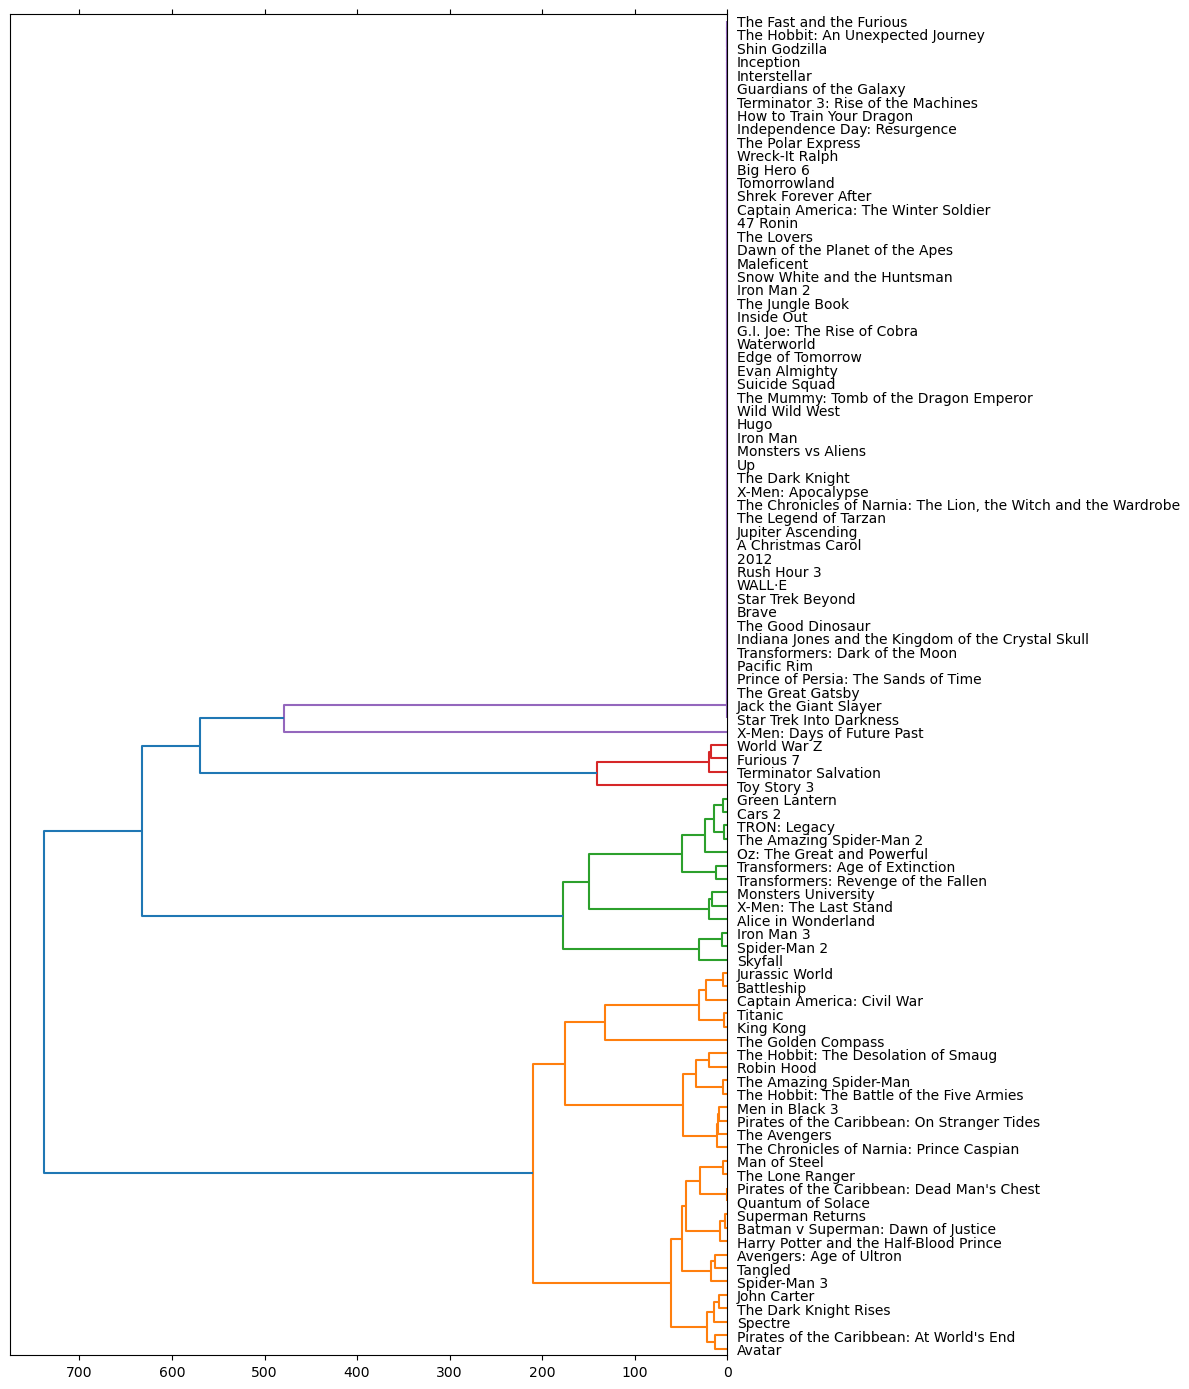

In [29]:
plot_hierarchical_clusters(linkage_matrix, p=100, movie_data=df, figure_size=(12, 14))

Can you find more interesting patterns? Which movies do you think do not belong together in the same clusters? Can we build better clusters? Can we recommend similar movies to watch based on clustering movies together? These are some interesting questions to ponder, and I will leave them for you to look at and explore further.